In [1]:
import polars as pl
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read data
df = pl.read_csv("../data/hltv_players_final.csv")

In [3]:
# Convert columns with value % to float
percent_cols = ["ROUND_SWING", "KAST", "MULTI_KILL", "Headshot_pct"]
for col in percent_cols:
    df = df.with_columns(
        pl.col(col)
        .str.strip_chars("+%")
        .cast(pl.Float64)
)

In [4]:
# Drop top weapon and top weapon percent columns
df = df.drop(["top_weapon", "top_weapon_pct"])

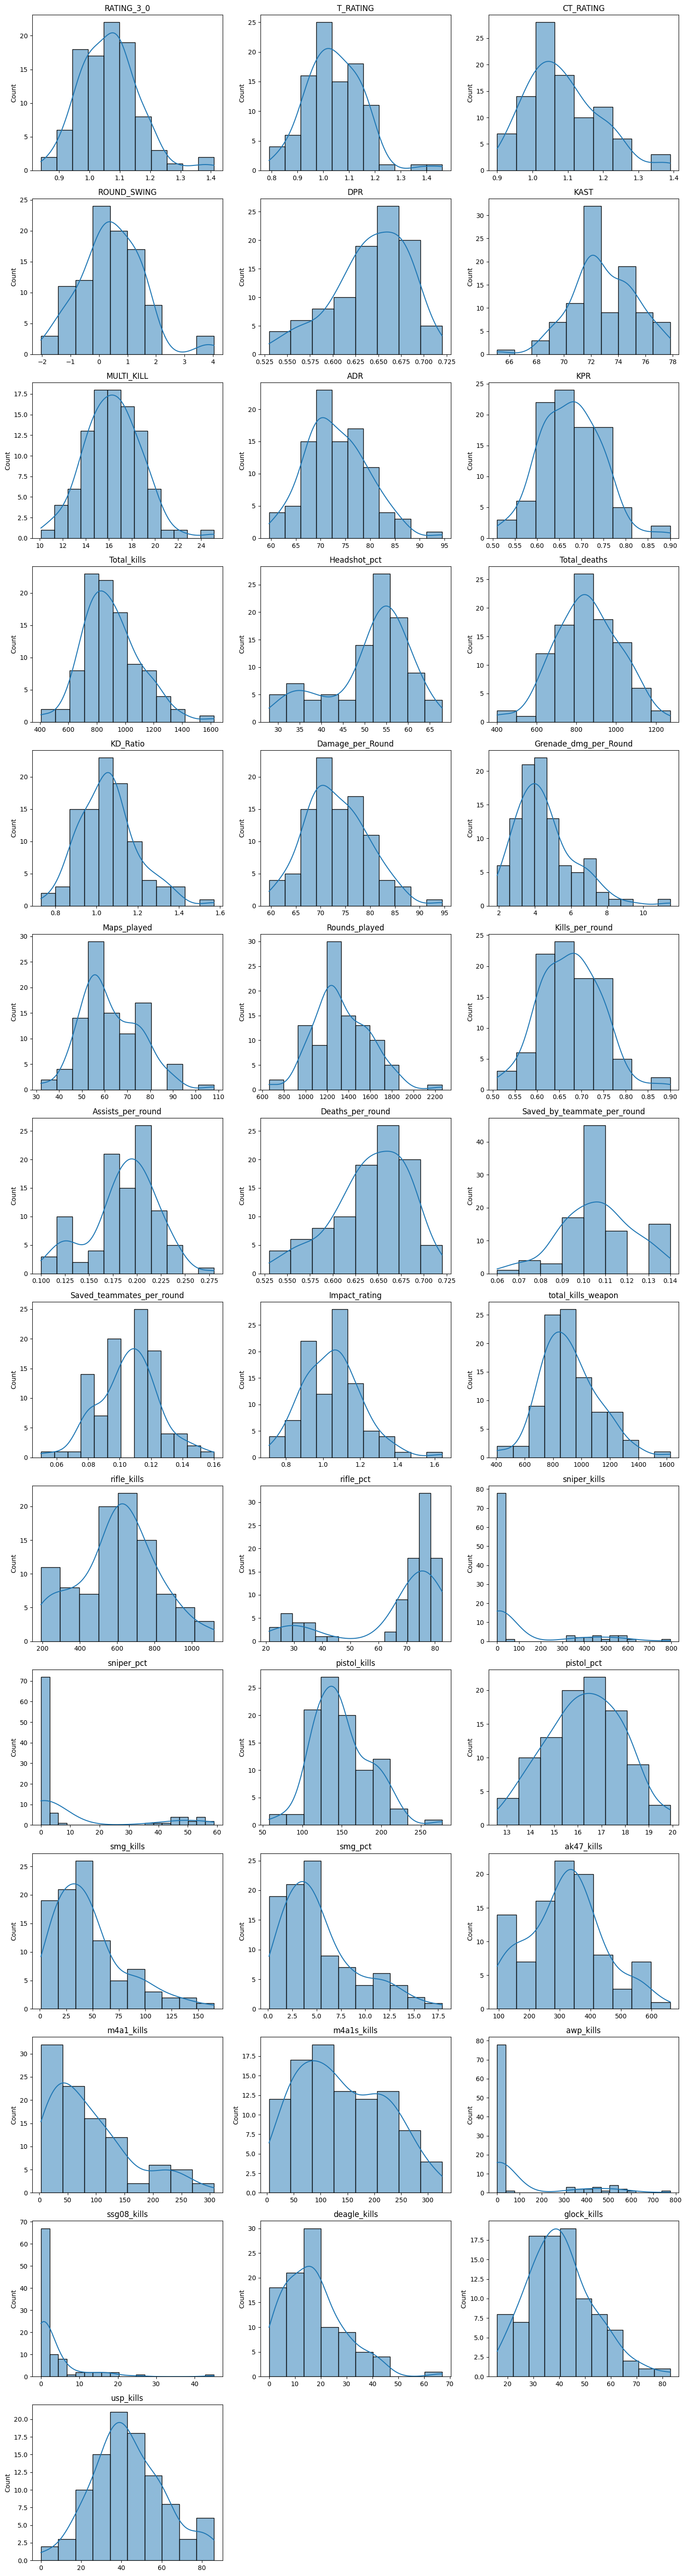

In [5]:
numeric_cols = [col for col in df.columns if df[col].dtype.is_numeric() and col != "player_id"]
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# Columns such as sniper_kills, sniper_pct, awp_kills, and ssg08_kills contain large number of zeros. Log transform these columns
log_cols = ["sniper_kills", "sniper_pct", "awp_kills", "ssg08_kills"]
for col in log_cols:
    df = df.with_columns(
        pl.col(col).log1p().alias(f"{col}_log")
    )


In [7]:
X = df.drop(["player_name", "player_fullname", "sniper_kills", "sniper_pct", "awp_kills", "ssg08_kills"]).to_pandas().set_index("player_id")

In [8]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

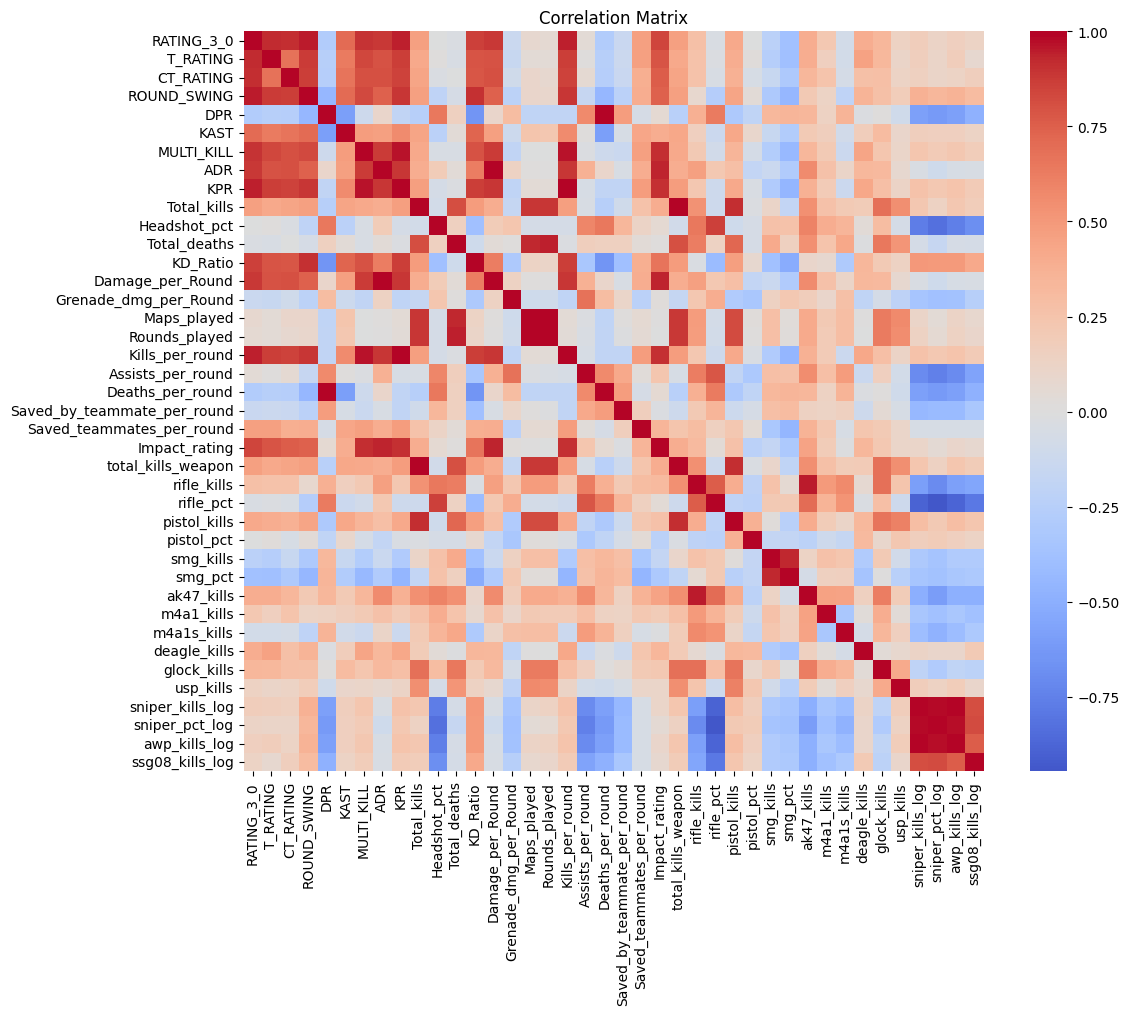

In [9]:
feature_cols = X.columns
# Correlation matrix
corr_matrix = np.corrcoef(X_scaled, rowvar=False)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm',
            center=0, square=True, ax=ax,
            xticklabels=feature_cols, yticklabels=feature_cols)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

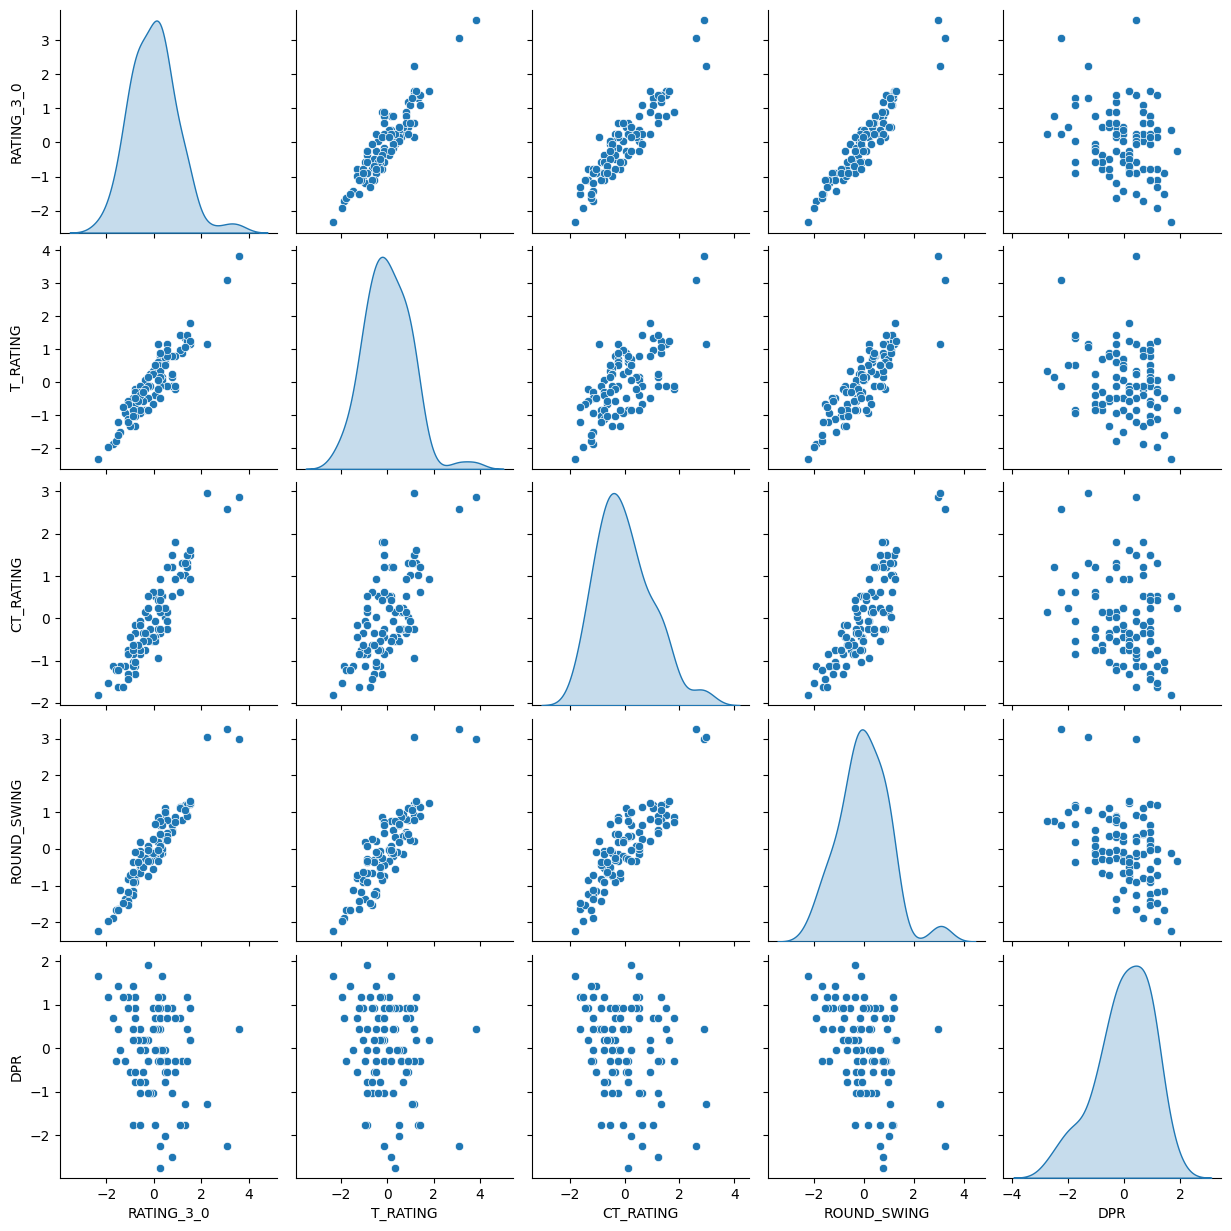

In [29]:
# Pair plot
df_scaled = pd.DataFrame(X_scaled[:, :5], columns=X.columns[:5])

sns.pairplot(df_scaled, diag_kind='kde')
plt.savefig("../images/pairplot.jpg")
plt.show()


In [32]:
# PCA on the scaled data
pca = PCA() 
X_pca = pca.fit_transform(X_scaled)
print(f"Original number of features: {X.shape[1]}")
print(f"Number of features after PCA: {X_pca.shape[1]}")

Original number of features: 40
Number of features after PCA: 40


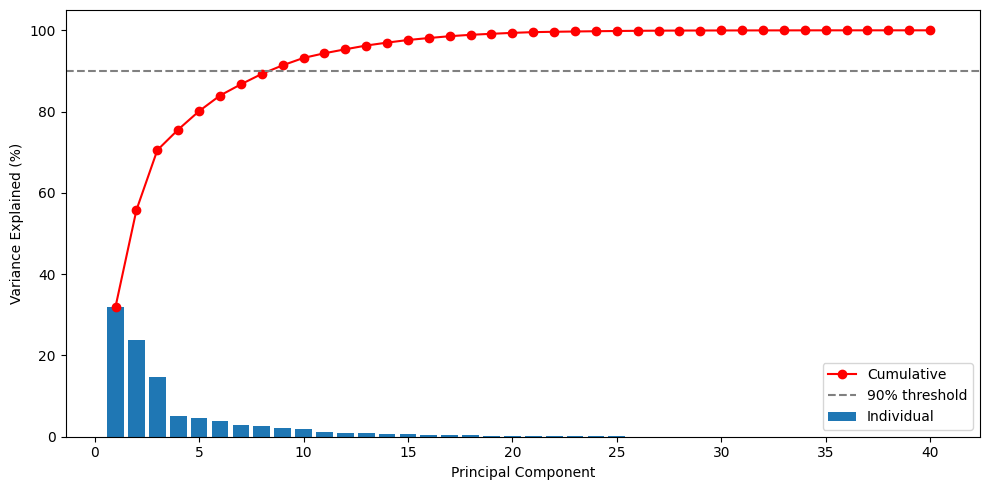

In [33]:
explained = pca.explained_variance_ratio_ * 100
cumulative = explained.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained) + 1), explained, label='Individual')
ax.plot(range(1, len(explained) + 1), cumulative, 'o-', color='red', label='Cumulative')
ax.axhline(90, linestyle='--', color='gray', label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.legend()
fig.savefig("../images/scree_plot.jpg")
plt.tight_layout()
plt.show()

In [34]:
# Keep 90% of variance
pca = PCA(n_components=0.9) 
X_pca = pca.fit_transform(X_scaled)

In [35]:
for i, component in enumerate(pca.components_):
    print(f"\nPC{i+1}:")
    weights = sorted(zip(feature_cols, component), key=lambda x: abs(x[1]), reverse=True)
    for feat, weight in weights:
        print(f"  {feat:30s} {weight:+.4f}")



PC1:
  KD_Ratio                       +0.2577
  KPR                            +0.2576
  Kills_per_round                +0.2576
  ROUND_SWING                    +0.2574
  RATING_3_0                     +0.2558
  MULTI_KILL                     +0.2432
  T_RATING                       +0.2370
  CT_RATING                      +0.2322
  Impact_rating                  +0.2179
  ADR                            +0.2140
  Damage_per_Round               +0.2140
  total_kills_weapon             +0.1947
  KAST                           +0.1947
  Total_kills                    +0.1945
  pistol_kills                   +0.1847
  smg_pct                        -0.1447
  Saved_teammates_per_round      +0.1324
  Deaths_per_round               -0.1187
  DPR                            -0.1187
  deagle_kills                   +0.1187
  glock_kills                    +0.1164
  sniper_kills_log               +0.1134
  awp_kills_log                  +0.1112
  ak47_kills                     +0.1007
  sniper_p

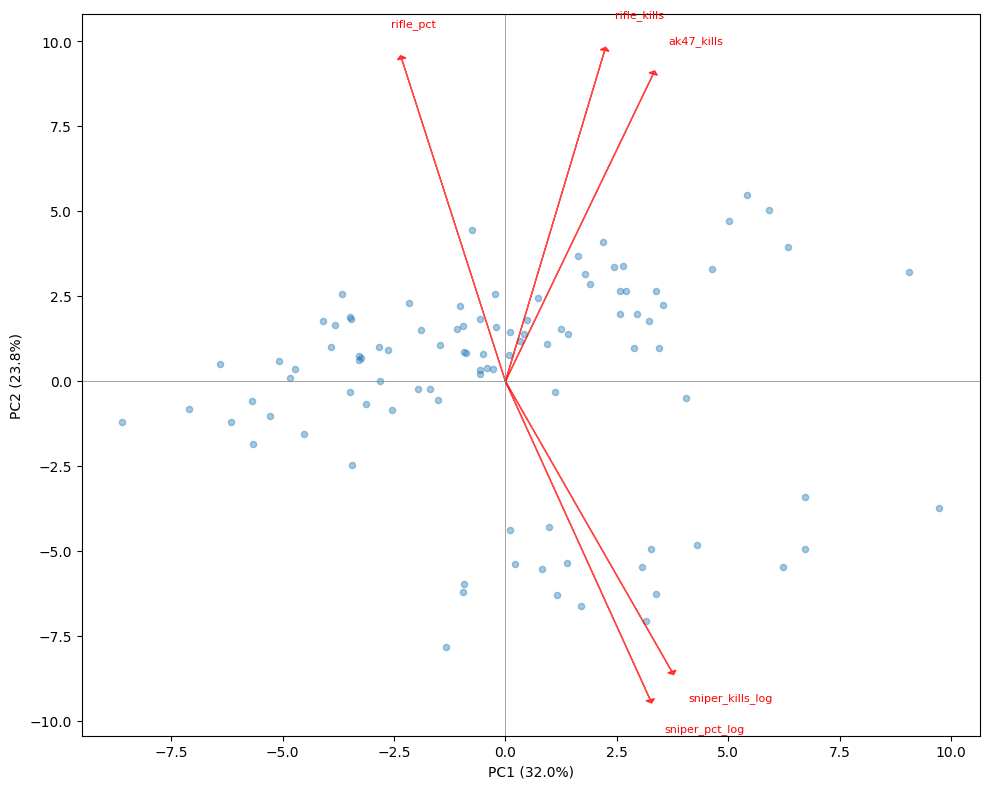

In [31]:
# Biplot with the first 2 pc
scores = X_pca[:, :2]
loadings = pca.components_[:2].T  # shape (n_features, 2)

scale = np.max(np.abs(scores)) / np.max(np.abs(loadings))

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(scores[:, 0], scores[:, 1], alpha=0.4, s=20)

top_idx = np.argsort(np.linalg.norm(loadings, axis=1))[-5:]

for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0] * scale, loadings[i, 1] * scale,
                head_width=0.2, head_length=0.1, fc='red', ec='red', alpha=0.7)
        ax.text(loadings[i, 0] * scale * 1.1, loadings[i, 1] * scale * 1.1,
                feature_cols[i], fontsize=8, color='red')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
fig.savefig("../images/biplot.jpg")
plt.show()

In [16]:
# Save data to pickle
import pickle

data = {
    'df': df,
    'X': X,
    'X_scaled': X_scaled,
    'X_pca': X_pca,
    'pca': pca,
    'feature_cols': feature_cols,
}

with open('../data/pca_data.pkl', 'wb') as f:
    pickle.dump(data, f)